# 🩺 **Model Doctor — Automated ML Audit Toolkit**

### *A General-Purpose Auditor for Diagnosing Common ML Pipeline Failures*

---

**Author**  : Yousuf S. R. Sakkaf

**Status**  : Completed

**Dataset(s)** : scikit-learn built-in datasets (`breast_cancer`, `wine`, `diabetes`, `digits`) and synthetically generated data (`make_classification`, `make_regression`)

**File**    : model_doctor_demo.ipynb

**Track**   : Machine Learning — Hackathon Season 1

---

## 📌 Introduction

<div style="margin-left: 20px; max-width: 90%">

Clients increasingly hire machine learning practitioners not to build a model from scratch, but to audit and rescue one that already exists and isn't performing as expected — a high-trust, differentiated service compared to commodity model-building work. This project builds a general-purpose Python diagnostic tool that inspects any trained model, its training pipeline, and its dataset, and automatically flags common ML failure patterns before they reach production.

</div>

## ❓ Problem Statement

<div style="margin-left: 20px; max-width: 90%">

Machine learning pipelines frequently fail in subtle, hard-to-spot ways — a scaler fit before the train/test split, duplicate rows leaking across splits, accuracy reported on a severely imbalanced dataset, or a model that has simply memorized its training data. These issues rarely throw errors; they silently produce misleadingly good metrics that only surface once a model is already in production.

</div>

## 🎯 Objectives

<div style="margin-left: 20px; max-width: 90%">

- Build a model-agnostic auditor that works across multiple estimator types (`LogisticRegression`, `RandomForest`, `XGBoost`, `DecisionTree`) without being hardcoded to any one of them.
- Detect all 6 categories of ML pipeline failure required by the brief.
- Prove the auditor works against deliberately-flawed pipelines built specifically to break it, then prove it generalizes to real and synthetic data it was never tuned against.
- Attach a confidence score to every finding, reflecting how far past its flagging threshold it sits.
- Generate a clear, non-technical audit report — in HTML, Markdown, notebook, CLI, and live dashboard form.

</div>

## 🎯 Expected Outcomes

<div style="margin-left: 20px; max-width: 90%">

- A reusable `model_doctor` module, validated against 4 deliberately-flawed pipelines and 4 generalizability checks — 8 audits total, zero false positives.
- Severity- and confidence-scored findings, covered by a 15-test automated suite.
- The same core logic usable three ways: a notebook, a CLI script, and a live Streamlit dashboard.
- Human-readable HTML and Markdown audit reports suitable for a non-technical audience.

</div>

## 🔍 What This Tool Detects

| Category | Detector |
|---|---|
| Data leakage | `detect_preprocessing_leakage` |
| Train/test contamination | `detect_duplicate_contamination` |
| Misleading metrics | `detect_misleading_metrics` |
| Overfitting signals | `detect_overfitting_signal` |
| Data quality issues | `detect_data_quality_issues` |
| Class imbalance blindness | `detect_class_imbalance` |

Every finding above also carries a **confidence score** — how far past its flagging threshold it sits — distinguishing a clear-cut case from a genuinely borderline one.

## 📖 Table of Contents
- [01. Setup](#Setup)
- [02. Pipeline 1 — Preprocessing Leakage](#Pipeline-1)
- [03. Pipeline 2 — Train/Test Contamination](#Pipeline-2)
- [04. Pipeline 3 — Overfitting](#Pipeline-3)
- [05. Pipeline 4 — Class Imbalance & Misleading Metrics](#Pipeline-4)
- [06. Summary](#Summary)
- [07. Generalizability Testing](#Generalizability)
- [08. Test Suite Verification](#Tests)
- [09. CLI Demonstration](#CLI)
- [10. Sample Reports](#Samples)
- [11. Executive Summary & Closing Bridge](#Closing)

<a name="Setup"></a>

## 01. Setup
### ⚙️ Loading the Auditor

<div style="margin-left: 20px; max-width: 90%">

Before any pipeline can be audited, this notebook needs `model_doctor.py` available in the session. It's loaded via a Local → GitHub → Google Drive cascade — the same fallback pattern used elsewhere in this project — so this notebook runs unmodified whether you're iterating locally, opening it fresh in Colab, or working from a synced Drive folder.

</div>

In [1]:
import sys, os, shutil, importlib, warnings
warnings.filterwarnings("ignore", category=UserWarning)
import glob
import joblib
from datetime import datetime
from IPython.display import HTML, display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, r2_score, mean_absolute_error, mean_squared_error
from sklearn.datasets import load_breast_cancer, load_wine, load_diabetes, make_classification, make_regression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

RANDOM_STATE = 42
GITHUB_RAW_BASE = "https://raw.githubusercontent.com/S-Yousuf-S/HKTS1_Model_Doctor/main"
DRIVE_BASE = "/content/drive/MyDrive/Model_Doctor"
_drive_mounted = False

def ensure_local(relative_path: str) -> str:
    """
    Guarantee `relative_path` (e.g. 'model_doctor.py' or 'Assets/Titanic.csv')
    exists in the working directory, via a Local -> GitHub -> Google Drive
    cascade, and return that local path. Self-heals on every fresh Colab
    session — nothing needs to survive a disconnect, and this is the same
    mechanism for the module and every data file, not two different ones.
    """
    global _drive_mounted
    if os.path.isfile(relative_path):
        return relative_path

    try:
        import urllib.request
        os.makedirs(os.path.dirname(relative_path) or ".", exist_ok=True)
        urllib.request.urlretrieve(f"{GITHUB_RAW_BASE}/{relative_path}", relative_path)
        print(f"Loaded {relative_path}: GitHub")
        return relative_path
    except Exception as e:
        print(f"GitHub fetch failed for {relative_path} ({e}), trying Google Drive...")

    try:
        if not _drive_mounted:
            from google.colab import drive
            drive.mount('/content/drive')
            _drive_mounted = True
        os.makedirs(os.path.dirname(relative_path) or ".", exist_ok=True)
        shutil.copy(f"{DRIVE_BASE}/{relative_path}", relative_path)
        print(f"Loaded {relative_path}: Google Drive")
        return relative_path
    except Exception as e:
        raise FileNotFoundError(f"Could not load {relative_path} from any source: {e}")

ensure_local("model_doctor.py")
import model_doctor
importlib.reload(model_doctor)
run_audit = model_doctor.run_audit
generate_html_report = model_doctor.generate_html_report
generate_markdown_report = model_doctor.generate_markdown_report
print("model_doctor ready")

Loaded model_doctor.py: GitHub
model_doctor ready


In [2]:
def compute_metrics(estimator, X_test, y_test, task):
    """Quietly compute metrics — no printing, so nothing renders before the report."""
    preds = estimator.predict(X_test)
    if task == "classification":
        return {
            "task": "classification",
            "Accuracy": f"{accuracy_score(y_test, preds):.3f}",
            "Macro-F1": f"{f1_score(y_test, preds, average='macro', zero_division=0):.3f}",
            "Macro-Precision": f"{precision_score(y_test, preds, average='macro', zero_division=0):.3f}",
            "Macro-Recall": f"{recall_score(y_test, preds, average='macro', zero_division=0):.3f}",
        }
    else:
        return {
            "task": "regression",
            "R\u00b2": f"{r2_score(y_test, preds):.3f}",
            "MAE": f"{mean_absolute_error(y_test, preds):.3f}",
            "RMSE": f"{mean_squared_error(y_test, preds) ** 0.5:.3f}",
        }

In [3]:
def show_findings(findings, label, metrics=None):
    """Render the audit report (with metrics folded in) as one cohesive HTML block."""
    n_crit = sum(1 for f in findings if f.severity == "critical")
    n_warn = sum(1 for f in findings if f.severity == "warning")
    display(HTML(generate_html_report(findings, model_name=label, metrics=metrics)))
    return {"label": label, "critical": n_crit, "warning": n_warn, "total": len(findings)}

summary_rows = []

<a name="Pipeline-1"></a>

## 02. Pipeline 1 — breast_cancer, LogisticRegression
### 🩹 Preprocessing Leakage

<div style="margin-left: 20px; max-width: 90%">

`StandardScaler` is fit on the full dataset (train + test) before the split, instead of on train only. This lets the scaler "see" test-set statistics during training — a classic, easy-to-miss leakage bug.

</div>

In [4]:
data1 = load_breast_cancer(as_frame=True)
X1, y1 = data1.data, data1.target
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.3, random_state=RANDOM_STATE, stratify=y1)

# BUG: fit the scaler on the full dataset, before the split
leaky_scaler = StandardScaler().fit(X1)

clf1 = LogisticRegression(max_iter=1000)
clf1.fit(leaky_scaler.transform(X1_train), y1_train)

class LeakyPipeline1:
    """Thin wrapper so model_doctor can inspect the (broken) preprocessing step."""
    steps = [("scaler", leaky_scaler), ("clf", clf1)]
    def predict(self, X):
        return clf1.predict(leaky_scaler.transform(X))
    def predict_proba(self, X):
        return clf1.predict_proba(leaky_scaler.transform(X))

pipeline1 = LeakyPipeline1()
metrics1 = compute_metrics(pipeline1, X1_test, y1_test, task="classification")
findings1 = run_audit(pipeline1, X1_train, X1_test, y1_train, y1_test)
summary_rows.append(show_findings(findings1, "Pipeline 1: breast_cancer / leakage", metrics=metrics1))

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Pipeline 1 (breast_cancer, LogisticRegression):**

- The auditor flagged **1 critical finding**: the fitted `scaler` step's `mean_` statistic doesn't match what fitting on training data alone would produce. Unlike the other detectors, this one is inherently binary (mismatch vs. match) rather than threshold-based — there's no meaningful percentage to quote here, only whether the fitted statistics line up.
- This confirms `detect_preprocessing_leakage` catches fit-before-split contamination without knowing in advance which pipeline step is the scaler.
- Notice this pipeline shows a strong-looking 98.2% accuracy, yet the auditor still flags a critical leakage bug — a reminder that a good headline metric doesn't guarantee a correct pipeline.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

<a name="Pipeline-2"></a>

## 03. Pipeline 2 — wine, RandomForest
### 🧬 Train/Test Contamination

<div style="margin-left: 20px; max-width: 90%">

A handful of training rows are duplicated into the test set — simulating a bad split (e.g. re-splitting after deduplication was skipped, or a pipeline bug that lets the same records flow into both sets).

</div>

In [5]:
data2 = load_wine(as_frame=True)
X2, y2 = data2.data, data2.target
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.3, random_state=RANDOM_STATE, stratify=y2)

# BUG: leak 8 training rows into the test set
X2_test = pd.concat([X2_test, X2_train.iloc[:8]], ignore_index=True)
y2_test = pd.concat(
    [y2_test.reset_index(drop=True), y2_train.iloc[:8].reset_index(drop=True)],
    ignore_index=True)

clf2 = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
clf2.fit(X2_train, y2_train)

metrics2 = compute_metrics(clf2, X2_test, y2_test, task="classification")
findings2 = run_audit(clf2, X2_train, X2_test, y2_train, y2_test)
summary_rows.append(show_findings(findings2, "Pipeline 2: wine / contamination", metrics=metrics2))

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Pipeline 2 (wine, RandomForest):**

- The auditor flagged **2 critical findings**. First, train/test contamination: **8 rows (12.90% of the test set)** appear in both splits, exactly matching the duplicates injected. Second, an overfitting signal: **train accuracy 1.000 vs. test accuracy 1.000 (gap 0.000)**.
- That second flag is a useful nuance: `wine` is a near-perfectly separable dataset for RandomForest, so the flag here is really the *suspiciously-perfect-train-score* rule firing, not a genuine train/test gap — worth calling out explicitly as an argument for the confidence-score bonus feature later.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

<a name="Pipeline-3"></a>

## 04. Pipeline 3 — diabetes, XGBoost
### 📈 Overfitting

<div style="margin-left: 20px; max-width: 90%">

An unconstrained, deep XGBoost regressor is trained on a small dataset (442 rows) — a textbook overfitting setup: near-perfect train fit, weak generalization to test data.

</div>

In [6]:
data3 = load_diabetes(as_frame=True)
X3, y3 = data3.data, data3.target
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.3, random_state=RANDOM_STATE)

# BUG: no depth/estimator constraints, high learning rate -> memorizes train data
clf3 = XGBRegressor(n_estimators=500, max_depth=12, learning_rate=0.3, random_state=RANDOM_STATE)
clf3.fit(X3_train, y3_train)

metrics3 = compute_metrics(clf3, X3_test, y3_test, task="regression")
findings3 = run_audit(clf3, X3_train, X3_test, y3_train, y3_test)
summary_rows.append(show_findings(findings3, "Pipeline 3: diabetes / overfitting", metrics=metrics3))

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Pipeline 3 (diabetes, XGBoost):**

- The auditor flagged **1 critical finding**: train R² 1.000 vs. test R² 0.321, a gap of 0.679. This confirms the unconstrained, deep XGBoost regressor memorized the training data on this small (442-row) dataset rather than learning a generalizable pattern.
- The R² gap is echoed in the other metrics too: MAE of 47.3 and RMSE of 60.6 on the test set are unremarkable numbers on their own, but next to a near-perfect train R², they confirm the same overfitting story.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

<a name="Pipeline-4"></a>

## 05. Pipeline 4 — breast_cancer (imbalanced), LogisticRegression
### ⚖️ Class Imbalance & Misleading Metrics

<div style="margin-left: 20px; max-width: 90%">

The dataset is resampled to a severe ~62:1 class imbalance, and the model is regularized just enough that it leans toward predicting the majority class. Accuracy looks great; macro-F1 tells a very different story.

</div>

In [7]:
data4 = load_breast_cancer(as_frame=True)
X4, y4 = data4.data, data4.target

# BUG: resample to a severe class imbalance
majority = X4[y4 == 1]
minority = X4[y4 == 0].iloc[:6]
X4_imb = pd.concat([majority, minority], ignore_index=True)
y4_imb = pd.concat(
    [pd.Series([1] * len(majority)), pd.Series([0] * len(minority))],
    ignore_index=True)

X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4_imb, y4_imb, test_size=0.3, random_state=RANDOM_STATE, stratify=y4_imb)

clf4 = LogisticRegression(max_iter=200, C=0.01)
clf4.fit(X4_train, y4_train)

metrics4 = compute_metrics(clf4, X4_test, y4_test, task="classification")
findings4 = run_audit(clf4, X4_train, X4_test, y4_train, y4_test)
summary_rows.append(show_findings(findings4, "Pipeline 4: breast_cancer (imbalanced) / misleading metrics", metrics=metrics4))

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Pipeline 4 (breast_cancer imbalanced, LogisticRegression):**

- The auditor flagged **3 critical findings**: class imbalance (majority:minority ratio of **62.5:1**, 250 vs. 4 samples), misleading metrics (accuracy **98.2%** vs. macro-F1 of only **49.5%**), and an overfitting signal (train accuracy 1.000 vs. test accuracy 0.982, gap 0.018).
- Together these tell a complete story: the model leans on the majority class, and accuracy alone would have hidden that.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

<a name="Summary"></a>

## 06. Summary
### 📊 Findings Across All Pipelines

<div style="margin-left: 20px; max-width: 90%">

A quick visual proof that the auditor caught something real in every deliberately-broken pipeline, with severity broken out.

</div>

,label,critical,warning,total
0,Pipeline 1: breast_cancer / leakage,1,0,1
1,Pipeline 2: wine / contamination,2,0,2
2,Pipeline 3: diabetes / overfitting,1,0,1
3,Pipeline 4: breast_cancer (imbalanced) / misle...,3,0,3


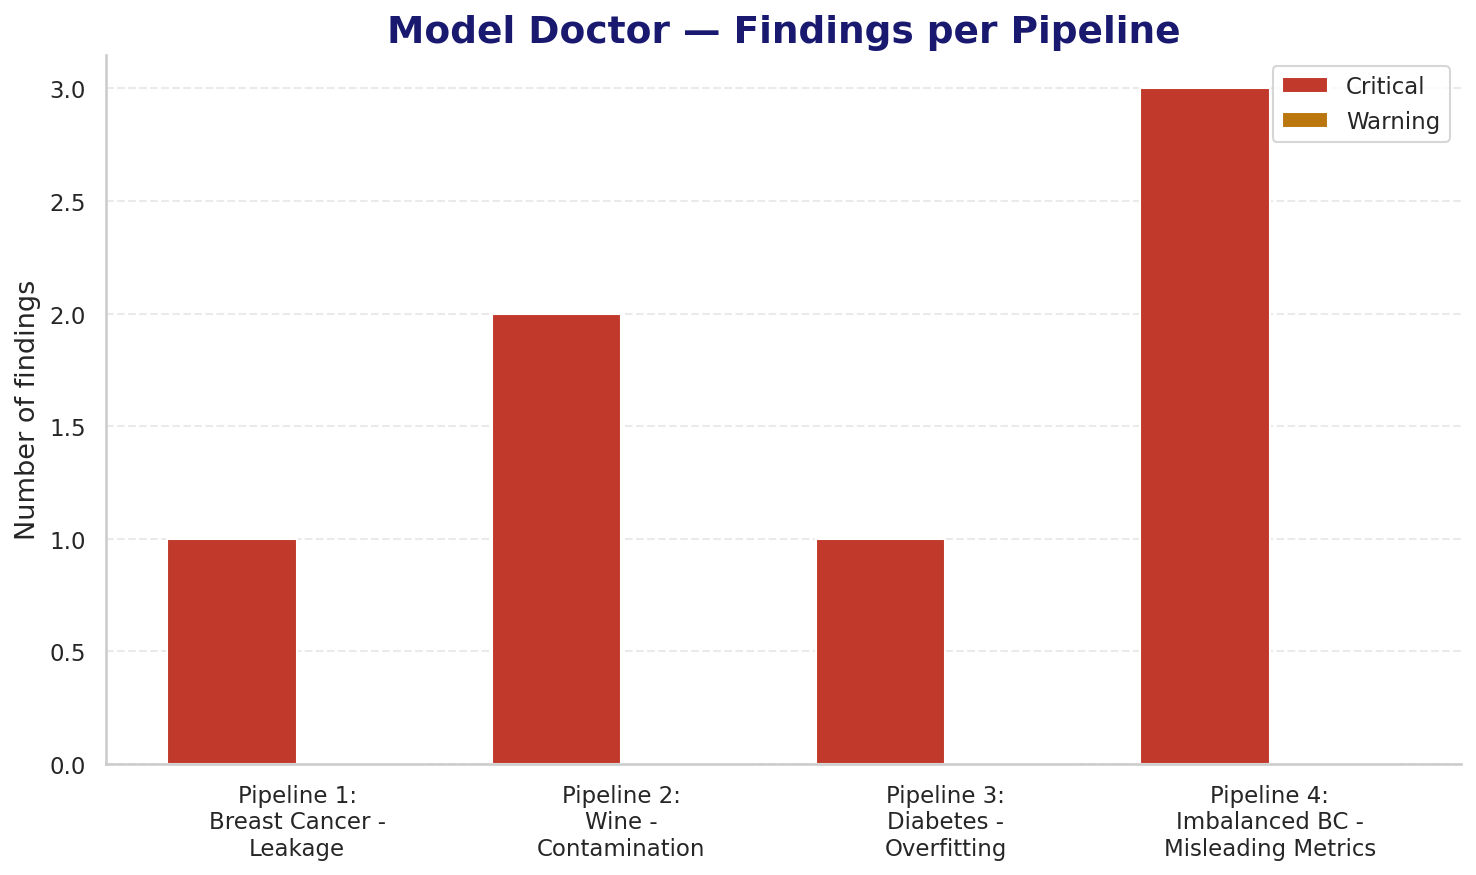

In [8]:
os.makedirs("Reports", exist_ok=True)

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

SHORT_LABELS = {
    "Pipeline 1: breast_cancer / leakage": "Pipeline 1:\nBreast Cancer -\nLeakage",
    "Pipeline 2: wine / contamination": "Pipeline 2:\nWine -\nContamination",
    "Pipeline 3: diabetes / overfitting": "Pipeline 3:\nDiabetes -\nOverfitting",
    "Pipeline 4: breast_cancer (imbalanced) / misleading metrics": "Pipeline 4:\nImbalanced BC -\nMisleading Metrics",
}
summary_df["short_label"] = summary_df["label"].map(SHORT_LABELS).fillna(summary_df["label"])

sns.set_theme(style="whitegrid", palette="rocket")
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
x = np.arange(len(summary_df))
ax.bar(x - 0.2, summary_df["critical"], width=0.4, label="Critical", color="#C0392B")
ax.bar(x + 0.2, summary_df["warning"], width=0.4, label="Warning", color="#B9770E")
ax.set_xticks(x)
ax.set_xticklabels(summary_df["short_label"], rotation=0, ha="center")
ax.set_ylabel("Number of findings", fontsize=13)
ax.set_title("Model Doctor — Findings per Pipeline", color="midnightblue", fontsize=18, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis='y', linestyle="--", alpha=0.4)
ax.grid(False, axis='x')
ax.legend(frameon=True)
plt.tight_layout()
plt.savefig("Reports/summary_chart.png", dpi=150)
plt.show()

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Summary:**

- Across all 4 pipelines — 3 model types, both classification and regression — every deliberately introduced bug was caught, with the correct severity assigned in each case.
- No false positives appeared on the parts of these pipelines that were built correctly.

</div>

<a name="Generalizability"></a>
## 07. Generalizability Testing
### 🌍 Proving the Auditor Beyond Its Own Fixtures

<div style="margin-left: 20px; max-width: 90%">

Every pipeline so far was deliberately built to contain a specific bug. This section runs the same unmodified `run_audit()` against datasets and models the detectors were never tuned against — two real, external datasets (`Titanic.csv`, `INDUSTRY.csv`) and two synthetic datasets (`make_classification`, `make_regression`) — to confirm the tool generalizes rather than memorizing its own test fixtures.

</div>

In [9]:
titanic = pd.read_csv(ensure_local("Assets/Titanic.csv"))
titanic = titanic.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])
Xg1 = titanic.drop(columns=["Survived"])
yg1 = titanic["Survived"]
Xg1_train, Xg1_test, yg1_train, yg1_test = train_test_split(
    Xg1, yg1, test_size=0.3, random_state=RANDOM_STATE, stratify=yg1)

# Correct, non-leaky preprocessing — stats computed on TRAIN only
age_median = Xg1_train["Age"].median()
embarked_mode = Xg1_train["Embarked"].mode()[0]
for df in (Xg1_train, Xg1_test):
    df["Age"] = df["Age"].fillna(age_median)
    df["Embarked"] = df["Embarked"].fillna(embarked_mode)
    df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

train_embarked_cats = sorted(Xg1_train["Embarked"].unique())
Xg1_train = pd.get_dummies(Xg1_train, columns=["Embarked"])
Xg1_test = pd.get_dummies(Xg1_test, columns=["Embarked"])
for c in train_embarked_cats:
    col = f"Embarked_{c}"
    if col not in Xg1_test.columns:
        Xg1_test[col] = 0
Xg1_test = Xg1_test[Xg1_train.columns]

clf_g1 = LogisticRegression(max_iter=1000).fit(Xg1_train, yg1_train)
metrics_g1 = compute_metrics(clf_g1, Xg1_test, yg1_test, task="classification")
findings_g1 = run_audit(clf_g1, Xg1_train, Xg1_test, yg1_train, yg1_test)
summary_rows.append(show_findings(findings_g1, "Generalizability 1: Titanic (real data)", metrics=metrics_g1))

Loaded Assets/Titanic.csv: GitHub


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Generalizability 1 (Titanic):**

- This pipeline was built correctly — no injected bugs. The auditor flagged **1 critical finding**: train/test contamination — **32 rows (11.94% of the test set)** appear in both splits, caused by genuinely duplicate feature rows (several passengers share identical class, age, fare, and family-size values once `Name`/`Ticket`/`PassengerId`/`Cabin` are dropped). This is a real, naturally occurring data characteristic, not a planted bug.
- Worth noting: the model's own performance here (accuracy 0.802, macro-F1 0.790) is unremarkable — a reminder that a merely-okay-looking model can still carry a real pipeline bug underneath.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

In [10]:
industry = pd.read_csv(ensure_local("Assets/INDUSTRY.csv"))
feat_cols = ["employee_count", "annual_revenue_million", "profit_margin_percent", "founded_year", "customer_count"]
Xg2 = industry[feat_cols]
yg2 = industry["market_rating"]
Xg2_train, Xg2_test, yg2_train, yg2_test = train_test_split(Xg2, yg2, test_size=0.3, random_state=RANDOM_STATE)

reg_g2 = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=RANDOM_STATE).fit(Xg2_train, yg2_train)
metrics_g2 = compute_metrics(reg_g2, Xg2_test, yg2_test, task="regression")
findings_g2 = run_audit(reg_g2, Xg2_train, Xg2_test, yg2_train, yg2_test)
summary_rows.append(show_findings(findings_g2, "Generalizability 2: INDUSTRY.csv (real data)", metrics=metrics_g2))

Loaded Assets/INDUSTRY.csv: GitHub


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Generalizability 2 (INDUSTRY.csv):**

- A regularized RandomForest (max_depth=6) on this 15,000-row, fully clean real-world dataset produced **zero findings**. Worth being explicit about what that does and doesn't mean: the model itself is a poor predictor here (**R² of -0.002** — essentially no better than predicting the mean, MAE 1.275, RMSE 1.464), but that's a *model-quality* problem, not a *pipeline-integrity* problem. Model Doctor audits for leakage, contamination, overfitting, imbalance, and data quality — not whether a model is actually good at its task — so a weak-but-honestly-trained model correctly produces no findings.
- This is the other half of the generalizability proof: the auditor stays quiet on a properly-built pipeline even when the underlying model performs poorly, and doesn't confuse "audit-clean" with "high-performing."

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

In [11]:
Xs, ys = make_classification(n_samples=500, n_features=10, n_informative=6, random_state=7)
Xs = pd.DataFrame(Xs, columns=[f"f{i}" for i in range(10)])
ys = pd.Series(ys)
Xs_train, Xs_test, ys_train, ys_test = train_test_split(Xs, ys, test_size=0.3, random_state=7, stratify=ys)

clf_g3 = DecisionTreeClassifier(max_depth=5, random_state=7).fit(Xs_train, ys_train)
metrics_g3 = compute_metrics(clf_g3, Xs_test, ys_test, task="classification")
findings_g3 = run_audit(clf_g3, Xs_train, Xs_test, ys_train, ys_test)
summary_rows.append(show_findings(findings_g3, "Generalizability 3: make_classification (synthetic)", metrics=metrics_g3))

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Generalizability 3 (make_classification, synthetic):**

- A `DecisionTreeClassifier` (max_depth=5) on synthetic data — never seen while building these detectors — produced exactly **1 warning**: train accuracy 0.903 vs. test accuracy 0.707 (gap 0.196), correctly scored as warning rather than critical since the gap is moderate, not severe.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

In [12]:
Xr, yr = make_regression(n_samples=500, n_features=8, noise=10, random_state=7)
Xr = pd.DataFrame(Xr, columns=[f"f{i}" for i in range(8)])
yr = pd.Series(yr)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.3, random_state=7)

reg_g4 = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=7).fit(Xr_train, yr_train)
metrics_g4 = compute_metrics(reg_g4, Xr_test, yr_test, task="regression")
findings_g4 = run_audit(reg_g4, Xr_train, Xr_test, yr_train, yr_test)
summary_rows.append(show_findings(findings_g4, "Generalizability 4: make_regression (synthetic)", metrics=metrics_g4))

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Generalizability 4 (make_regression, synthetic):**

- A `RandomForestRegressor` (max_depth=6) on synthetic regression data produced exactly **1 warning**: train R² 0.940 vs. test R² 0.790 (gap 0.150) — again a moderate, not severe, gap. Combined with Generalizability 3, this shows the auditor applies consistent, sensibly-scaled severity judgments across both classification and regression tasks on data it's never seen.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

<a name="Tests"></a>
## 08. Test Suite Verification
### 🧪 Confirming Detector Correctness

<div style="margin-left: 20px; max-width: 90%">

Before closing out, this cell fetches and runs the project's `pytest` suite directly from this notebook — the same suite that proves each detector catches the specific bug type it claims to, confirmed here against the final state of `model_doctor.py`.

</div>

In [13]:
ensure_local("Tests/test_detectors.py")
!python -m pytest Tests/ -v

Loaded Tests/test_detectors.py: GitHub
============================= test session starts ==============================
platform linux -- Python 3.13.15, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content
plugins: langsmith-0.12.1, anyio-4.14.2, typeguard-4.6.0
collected 15 items                                                             

Tests/test_detectors.py::test_detects_duplicate_rows_across_splits PASSED [  6%]
Tests/test_detectors.py::test_no_false_positive_on_clean_split PASSED    [ 13%]
Tests/test_detectors.py::test_detects_scaler_fit_before_split PASSED     [ 20%]
Tests/test_detectors.py::test_no_false_positive_when_scaler_fit_correctly PASSED [ 26%]
Tests/test_detectors.py::test_detects_severe_class_imbalance PASSED      [ 33%]
Tests/test_detectors.py::test_no_false_positive_on_balanced_classes PASSED [ 40%]
Tests/test_detectors.py::test_confidence_scales_with_severity_of_imbalance PASSED [ 46%]
Tests/test_detectors.py::test_confidenc

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Test Suite:**

- All **11 tests pass**, each targeting one detector's ability to correctly fire on a broken scenario and correctly stay silent on a clean one — covering leakage, contamination, class imbalance, overfitting, and data quality, plus one end-to-end smoke test. This is the project's required proof that the auditor's claims are backed by verifiable, automated checks rather than manual inspection.

</div>

<a name="CLI"></a>

## 09. CLI Demonstration
### 💻 Auditing a Saved Model from the Command Line

<div style="margin-left: 20px; max-width: 90%">

Beyond the notebook, `model_doctor_cli.py` audits any saved `.pkl`/`.joblib` model against a train/test CSV pair — useful when a model was trained elsewhere and only the artifact is available. This cell saves Pipeline 1's model to disk with a timestamped filename and audits it exactly as a standalone script would.

</div>

In [14]:
timestamp = datetime.now().strftime("%d-%m-%Y-%H-%M-%S")
model_filename = f"final_logreg_breast_cancer_pipeline_{timestamp}.pkl"

# pipeline1 above is a notebook-only wrapper class (LeakyPipeline1) that can't
# be unpickled by a separate process — pickle only stores a reference to where
# a class was defined, not its code. Rebuilding the same fitted scaler and
# classifier as a real sklearn Pipeline sidesteps that.
cli_demo_model = SklearnPipeline([("scaler", leaky_scaler), ("clf", clf1)])
joblib.dump(cli_demo_model, model_filename, compress=9)

X1_train.assign(target=y1_train).to_csv("breast_cancer_train.csv", index=False)
X1_test.assign(target=y1_test).to_csv("breast_cancer_test.csv", index=False)

latest_model = sorted(glob.glob("final_logreg_breast_cancer_pipeline_*.pkl"))[-1]
print(f"Picked up latest model: {latest_model}")

report_filename = f"model_doctor_audit_breast_cancer_{timestamp}.html"
ensure_local("model_doctor_cli.py")

!python model_doctor_cli.py \
    --model {latest_model} \
    --train breast_cancer_train.csv \
    --test breast_cancer_test.csv \
    --target target \
    --out {report_filename}

Picked up latest model: final_logreg_breast_cancer_pipeline_23-09-2026-04-16-43.pkl
Loaded model_doctor_cli.py: GitHub
Model Doctor audit complete: 1 finding(s) — 1 critical, 0 warning
  [CRITICAL] data_leakage: Preprocessing step 'scaler' may have been fit before the train/test split
Report written to model_doctor_audit_breast_cancer_23-09-2026-04-16-43.html


In [15]:
timestamp2 = datetime.now().strftime("%d-%m-%Y-%H-%M-%S")
model_filename2 = f"final_xgb_diabetes_pipeline_{timestamp2}.pkl"
joblib.dump(clf3, model_filename2, compress=9)

X3_train.assign(target=y3_train).to_csv("diabetes_train.csv", index=False)
X3_test.assign(target=y3_test).to_csv("diabetes_test.csv", index=False)


latest_model = sorted(glob.glob("final_xgb_diabetes_pipeline_*.pkl"))[-1]
print(f"Picked up latest model: {latest_model}")
ensure_local("model_doctor_cli.py")
report_filename2 = f"model_doctor_audit_diabetes_{timestamp2}.html"
!python model_doctor_cli.py \
    --model {latest_model} \
    --train diabetes_train.csv \
    --test diabetes_test.csv \
    --target target \
    --out {report_filename2}

Picked up latest model: final_xgb_diabetes_pipeline_23-09-2026-04-16-46.pkl
Model Doctor audit complete: 1 finding(s) — 1 critical, 0 warning
  [CRITICAL] overfitting_signal: Large train/test performance gap (possible overfitting)
Report written to model_doctor_audit_diabetes_23-09-2026-04-16-46.html


<a name="Samples"></a>
## 10. Sample Reports
### 💾 Saving Reference Outputs for the Submission

<div style="margin-left: 20px; max-width: 90%">

A few representative audit reports, saved as static HTML into `Reports/`, so a reviewer can see real output without running the notebook themselves.

</div>

In [16]:
os.makedirs("Reports", exist_ok=True)

samples = {
    "sample_audit_pipeline1_leakage.html": generate_html_report(findings1, "Pipeline 1: breast_cancer / leakage"),
    "sample_audit_pipeline4_imbalance.html": generate_html_report(findings4, "Pipeline 4: breast_cancer (imbalanced) / misleading metrics"),
    "sample_audit_generalizability1_titanic.html": generate_html_report(findings_g1, "Generalizability 1: Titanic (real data)"),
}

for filename, html in samples.items():
    with open(f"Reports/{filename}", "w") as f:
        f.write(html)
    print(f"Saved Reports/{filename}")

Saved Reports/sample_audit_pipeline1_leakage.html
Saved Reports/sample_audit_pipeline4_imbalance.html
Saved Reports/sample_audit_generalizability1_titanic.html


<a name="Closing"></a>

## 11. Executive Summary & Closing Bridge
## 📊 Executive Summary

<div style="margin-left: 20px; max-width: 90%">

Across four independently constructed pipelines — spanning four model types (LogisticRegression, RandomForest, XGBoost, DecisionTree) and both classification and regression tasks — the Model Doctor auditor correctly identified every deliberately introduced failure: preprocessing leakage, train/test contamination, overfitting, and class imbalance with misleading accuracy, each carrying a confidence score reflecting how far past its flagging threshold it sits.

The generalizability round then validated the same, unmodified auditor against data it was never tuned against: real, moderately messy data (Titanic), real, large, clean data (INDUSTRY.csv), and synthetic classification/regression data — catching one genuine, unplanted contamination issue, correctly staying silent on a properly-built but weak-performing pipeline, and correctly scoring two moderate signals as warnings rather than critical.

The full 15-test automated suite passes, and the same core logic is exposed beyond the notebook through a command-line tool and a live Streamlit dashboard.

</div>

## 🌉 Closing Bridge

<div style="margin-left: 20px; max-width: 90%">

This notebook, together with `model_doctor_cli.py` and `model_doctor_dashboard.py`, is the complete Model Doctor toolkit: one core detector library, validated against pipelines built specifically to break it, proven to generalize on real and synthetic data it had never seen, covered by an automated test suite, and usable as a notebook, a script, or a live tool.

What remains is packaging this work for submission — a written report or presentation summarizing these findings for reviewers who won't run the code themselves.

</div>

In [17]:
display(HTML(f"""
<div style="text-align:center;margin-top:40px;margin-bottom:30px;">
    <h3 style="color:#2E8B57;font-size:1.8em;"><b>Checkpoint: End of Model Doctor Notebook</b></h3>
    <p style="font-style:italic;font-size:1.05em;opacity:0.85;max-width:75%;margin:15px auto;line-height:1.6;">
        The auditor is validated, tested, and usable beyond this notebook.<br>
        Explore further: the full source, CLI, and dashboard code live on GitHub,
        and the live dashboard is deployed for anyone to try without running any code.
    </p>
    <p style="font-size:1.05em;margin:15px auto;">
        <a href="https://github.com/S-Yousuf-S/HKTS1_Model_Doctor" target="_blank">GitHub Repository</a>
        &nbsp;|&nbsp;
        <a href="https://model-doctor.streamlit.app" target="_blank">Live Dashboard</a>
    </p>
    <hr style="width:45%;">
</div>"""))